Average Monthly Savings: 21866.666666666668
Highest Spending Month: Jun


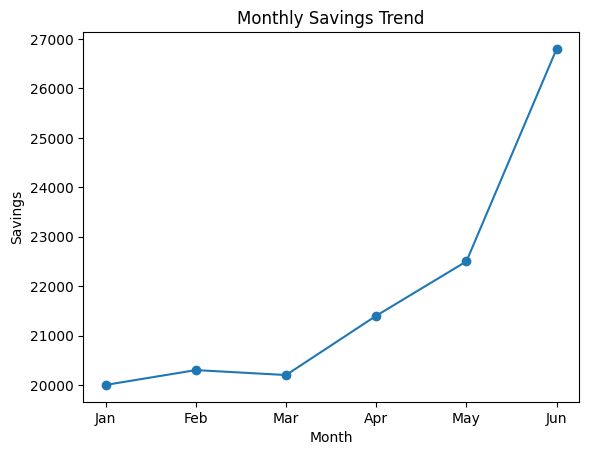

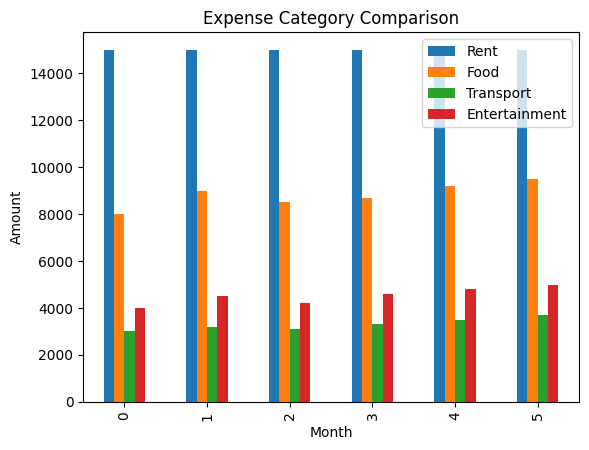

Predicted Savings for Next Month: 26046.666666666668
Model Accuracy (R2 Score): 0.7412563283083972


In [ ]:
# Personal Finance Tracker Dashboard

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Monthly financial data
data = {
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'],
    'Income': [50000, 52000, 51000, 53000, 55000, 60000],
    'Rent': [15000, 15000, 15000, 15000, 15000, 15000],
    'Food': [8000, 9000, 8500, 8700, 9200, 9500],
    'Transport': [3000, 3200, 3100, 3300, 3500, 3700],
    'Entertainment': [4000, 4500, 4200, 4600, 4800, 5000]
}

df = pd.DataFrame(data)
df

# Calculate total expenses
df['Total_Expenses'] = df[['Rent','Food','Transport','Entertainment']].sum(axis=1)

# Calculate savings
df['Savings'] = df['Income'] - df['Total_Expenses']

df

print("Average Monthly Savings:", df['Savings'].mean())

highest_spending_month = df.loc[df['Total_Expenses'].idxmax(), 'Month']
print("Highest Spending Month:", highest_spending_month)

plt.figure()
plt.plot(df['Month'], df['Savings'], marker='o')
plt.title("Monthly Savings Trend")
plt.xlabel("Month")
plt.ylabel("Savings")
plt.show()

df[['Rent','Food','Transport','Entertainment']].plot(kind='bar')
plt.title("Expense Category Comparison")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.show()

# Convert months into numerical values
X = np.array(range(len(df))).reshape(-1,1)
y = df['Savings']

# Train Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Predict next month's savings
future_month = np.array([[6]])
predicted_savings = model.predict(future_month)

print("Predicted Savings for Next Month:", predicted_savings[0])

predictions = model.predict(X)
print("Model Accuracy (R2 Score):", r2_score(y, predictions))

